<a href="https://colab.research.google.com/github/shreyasat27/mahework2025/blob/main/Final_ver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyscf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 MB 15.0 MB/s eta 0:00:00


In [ ]:
"""
MOLECULAR_SPIN_QUBIT_ASSESSMENT.py
Complete DiVincenzo Criteria Assessment for Molecular Spin Qubits
Uses pre-computed values from ORCA, PySCF, CASSCF, etc.
"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Dict, Tuple
import seaborn as sns

@dataclass
class MolecularProperties:
    """Container for pre-computed molecular properties from quantum chemistry software"""
    # From DFT Geometry Optimization (Tier 1)
    geometry_converged: bool = True
    no_imaginary_frequencies: bool = True
    homo_lumo_gap_ev: float = 2.5  # eV

    # From Multiplicity Calculations (Tier 1)
    ground_state_spin: float = 0.5  # S = 1/2
    energy_gap_to_next_state_ev: float = 0.3  # eV
    singlet_triplet_gap_ev: float = 0.000348  # eV (J = 2.81 cm⁻¹)

    # From EPR Properties (Tier 2 - ORCA/PySCF)
    hyperfine_tensor_principal: List[float] = None  # MHz
    g_tensor_principal: List[float] = None
    hyperfine_rms: float = 15.0  # MHz
    g_anisotropy: float = 0.005

    # From Multireference Calculations (Tier 3 - CASSCF/NEVPT2)
    caspt2_energy_gap_ev: float = 0.28  # eV
    spin_phonon_coupling_modes: List[float] = None  # cm⁻¹

    # From TD-DFT/SOC Calculations
    optical_transitions: List[Dict] = None
    spin_orbit_coupling_matrix: np.ndarray = None
    isc_rates: List[float] = None

    # From Exchange/Dipolar Calculations
    exchange_coupling_J_cm: float = 2.81  # cm⁻¹
    dipolar_coupling_MHz: float = 50.0  # MHz
    rabi_frequency_MHz: float = 10.0  # MHz

    # Experimental/Environmental Parameters
    temperature_K: float = 298.0
    magnetic_field_T: float = 0.35

class DiVincenzoAssessor:
    """
    Comprehensive assessment of molecular spin qubits against DiVincenzo criteria
    using pre-computed quantum chemistry results
    """

    def __init__(self):
        # Physical constants
        self.kB = 8.617333e-5  # eV/K
        self.mu_B = 5.788e-5   # eV/T
        self.h = 4.135667e-15  # eV·s
        self.cm_to_eV = 1.2398e-4

    def load_diradical_1c_properties(self) -> MolecularProperties:
        """Load pre-computed properties for Diradical 1(c)"""
        return MolecularProperties(
            # Tier 1: DFT Geometry & Multiplicity
            geometry_converged=True,
            no_imaginary_frequencies=True,
            homo_lumo_gap_ev=2.3,  # From DFT calculation

            # Spin ground state (from BS-DFT/NEVPT2)
            ground_state_spin=0.5,
            energy_gap_to_next_state_ev=0.25,  # To S=3/2 state
            singlet_triplet_gap_ev=0.000348,   # J = 2.81 cm⁻¹

            # Tier 2: EPR Properties (from ORCA)
            hyperfine_tensor_principal=[45.2, 38.7, 32.1],  # MHz - principal nitrogen
            g_tensor_principal=[2.008, 2.005, 2.002],
            hyperfine_rms=18.5,  # MHz - RMS over all nuclei
            g_anisotropy=0.006,

            # Tier 3: High-Accuracy (from CASPT2)
            caspt2_energy_gap_ev=0.26,
            spin_phonon_coupling_modes=[150, 280, 450],  # cm⁻¹ - strong coupling modes

            # Optical Properties (from TD-DFT/SOC)
            optical_transitions=[
                {'energy_ev': 1.8, 'oscillator_strength': 0.15, 'spin_char': 'singlet'},
                {'energy_ev': 2.1, 'oscillator_strength': 0.08, 'spin_char': 'triplet'}
            ],

            # Gate Operations
            exchange_coupling_J_cm=2.81,
            dipolar_coupling_MHz=42.3,
            rabi_frequency_MHz=12.5,

            # Experimental conditions
            temperature_K=298.0,
            magnetic_field_T=0.35
        )

    def criterion_1_well_defined_system(self, props: MolecularProperties) -> Dict:
        """Criterion 1: Well-defined Two-Level System"""
        score = 0
        details = []

        # Check geometry stability
        if props.geometry_converged and props.no_imaginary_frequencies:
            score += 2
            details.append("✓ Stable geometry (no imaginary frequencies)")
        else:
            details.append("✗ Geometry optimization issues")

        # Check HOMO-LUMO gap
        if props.homo_lumo_gap_ev > 1.5:
            score += 1
            details.append(f"✓ Large HOMO-LUMO gap ({props.homo_lumo_gap_ev:.2f} eV)")
        else:
            details.append(f"✗ Small HOMO-LUMO gap ({props.homo_lumo_gap_ev:.2f} eV)")

        # Check spin ground state isolation
        thermal_energy = self.kB * props.temperature_K
        if props.energy_gap_to_next_state_ev > 10 * thermal_energy:
            score += 2
            details.append(f"✓ Well-isolated ground state (ΔE = {props.energy_gap_to_next_state_ev:.3f} eV)")
        else:
            details.append(f"✗ Small gap to excited states (ΔE = {props.energy_gap_to_next_state_ev:.3f} eV)")

        return {
            'score': score,
            'max_score': 5,
            'details': details,
            'criterion': "Well-defined Two-Level System"
        }

    def criterion_2_initialization(self, props: MolecularProperties) -> Dict:
        """Criterion 2: Reliable Initialization"""
        score = 0
        details = []

        # Check for unique S=1/2 ground state
        if props.ground_state_spin == 0.5:
            score += 2
            details.append("✓ Unique S=1/2 ground state")
        else:
            details.append(f"✗ Ground state not S=1/2 (S={props.ground_state_spin})")

        # Check optical initialization pathways
        bright_transitions = [t for t in props.optical_transitions
                            if t['oscillator_strength'] > 0.1]
        if bright_transitions:
            score += 1
            details.append(f"✓ {len(bright_transitions)} bright optical transitions for initialization")
        else:
            details.append("✗ No bright optical transitions")

        # Check thermal initialization (Zeeman vs thermal energy)
        zeeman_splitting = 2 * props.g_tensor_principal[2] * self.mu_B * props.magnetic_field_T
        thermal_energy = self.kB * props.temperature_K

        if zeeman_splitting > thermal_energy:
            score += 1
            details.append(f"✓ Zeeman splitting ({zeeman_splitting*1e3:.1f} meV) > kT ({thermal_energy*1e3:.1f} meV)")
        else:
            details.append(f"✗ Zeeman splitting ({zeeman_splitting*1e3:.1f} meV) < kT ({thermal_energy*1e3:.1f} meV)")

        # Check spin-orbit coupling for ISC
        if props.spin_phonon_coupling_modes and len(props.spin_phonon_coupling_modes) > 0:
            score += 1
            details.append(f"✓ Spin-phonon coupling modes identified")
        else:
            details.append("✗ No identified spin-phonon coupling")

        return {
            'score': score,
            'max_score': 5,
            'details': details,
            'criterion': "Reliable Initialization"
        }

    def criterion_3_coherence_time(self, props: MolecularProperties) -> Dict:
        """Criterion 3: Long Coherence Time"""
        score = 0
        details = []

        # Hyperfine coupling assessment
        if props.hyperfine_rms < 20:  # MHz
            score += 2
            details.append(f"✓ Low hyperfine coupling (RMS = {props.hyperfine_rms:.1f} MHz)")
        elif props.hyperfine_rms < 50:
            score += 1
            details.append(f"~ Moderate hyperfine coupling (RMS = {props.hyperfine_rms:.1f} MHz)")
        else:
            details.append(f"✗ High hyperfine coupling (RMS = {props.hyperfine_rms:.1f} MHz)")

        # g-anisotropy assessment
        if props.g_anisotropy < 0.01:
            score += 2
            details.append(f"✓ Low g-anisotropy (Δg = {props.g_anisotropy:.4f})")
        else:
            details.append(f"✗ High g-anisotropy (Δg = {props.g_anisotropy:.4f})")

        # Estimate T2 from hyperfine (simplified model)
        T2_estimate_ns = 1e3 / props.hyperfine_rms  # Rough estimate
        if T2_estimate_ns > 100:
            score += 1
            details.append(f"✓ Estimated T₂ > 100 ns ({T2_estimate_ns:.0f} ns)")
        else:
            details.append(f"✗ Estimated T₂ < 100 ns ({T2_estimate_ns:.0f} ns)")

        # Spin-phonon coupling assessment
        strong_coupling_modes = [m for m in props.spin_phonon_coupling_modes if m < 500]
        if len(strong_coupling_modes) < 2:
            score += 1
            details.append("✓ Few low-frequency spin-phonon modes")
        else:
            details.append(f"✗ Multiple low-frequency spin-phonon modes")

        return {
            'score': score,
            'max_score': 6,
            'details': details,
            'T2_estimate_ns': T2_estimate_ns,
            'criterion': "Long Coherence Time"
        }

    def criterion_4_universal_gates(self, props: MolecularProperties) -> Dict:
        """Criterion 4: Universal Gate Operations"""
        score = 0
        details = []

        # Exchange coupling for two-qubit gates
        if 0.1 < abs(props.exchange_coupling_J_cm) < 100:
            score += 2
            details.append(f"✓ Suitable exchange coupling (J = {props.exchange_coupling_J_cm:.2f} cm⁻¹)")
        else:
            details.append(f"✗ Exchange coupling out of range (J = {props.exchange_coupling_J_cm:.2f} cm⁻¹)")

        # Dipolar coupling
        if props.dipolar_coupling_MHz > 1:
            score += 1
            details.append(f"✓ Non-zero dipolar coupling ({props.dipolar_coupling_MHz:.1f} MHz)")
        else:
            details.append("✗ Negligible dipolar coupling")

        # Rabi frequency for single-qubit gates
        if props.rabi_frequency_MHz > 1:
            score += 2
            details.append(f"✓ Reasonable Rabi frequency ({props.rabi_frequency_MHz:.1f} MHz)")
        else:
            details.append(f"✗ Low Rabi frequency ({props.rabi_frequency_MHz:.1f} MHz)")

        # Resonance conditions
        zeeman_frequency_GHz = (props.g_tensor_principal[2] * self.mu_B *
                               props.magnetic_field_T / self.h * 1e-9)
        details.append(f"  Zeeman frequency: {zeeman_frequency_GHz:.2f} GHz")

        if 1 < zeeman_frequency_GHz < 50:
            score += 1
            details.append("✓ Zeeman frequency in microwave range")
        else:
            details.append("✗ Zeeman frequency outside optimal range")

        return {
            'score': score,
            'max_score': 6,
            'details': details,
            'zeeman_frequency_GHz': zeeman_frequency_GHz,
            'criterion': "Universal Gate Operations"
        }

    def criterion_5_readout(self, props: MolecularProperties) -> Dict:
        """Criterion 5: Efficient Readout"""
        score = 0
        details = []

        # EPR readout - g-tensor anisotropy
        g_span = max(props.g_tensor_principal) - min(props.g_tensor_principal)
        if g_span > 0.001:
            score += 2
            details.append(f"✓ Anisotropic g-tensor (span = {g_span:.4f}) for EPR readout")
        else:
            details.append(f"✗ Nearly isotropic g-tensor")

        # Optical readout transitions
        spin_selective_transitions = [t for t in props.optical_transitions
                                   if 'spin_char' in t and t['oscillator_strength'] > 0.05]
        if spin_selective_transitions:
            score += 2
            details.append(f"✓ {len(spin_selective_transitions)} spin-selective optical transitions")
        else:
            details.append("✗ No spin-selective optical transitions")

        # Hyperfine structure for readout
        if len([h for h in props.hyperfine_tensor_principal if h > 10]) >= 2:
            score += 1
            details.append("✓ Resolvable hyperfine structure")
        else:
            details.append("✗ Limited hyperfine structure")

        # Distinct EPR signature
        avg_g = np.mean(props.g_tensor_principal)
        if 2.000 < avg_g < 2.010:
            score += 1
            details.append(f"✓ Characteristic organic radical g-value ({avg_g:.3f})")
        else:
            details.append(f"✗ Atypical g-value ({avg_g:.3f})")

        return {
            'score': score,
            'max_score': 6,
            'details': details,
            'criterion': "Efficient Readout"
        }

    def comprehensive_assessment(self, props: MolecularProperties) -> Dict:
        """Complete DiVincenzo criteria assessment"""
        criteria_results = {}

        criteria_results['criterion_1'] = self.criterion_1_well_defined_system(props)
        criteria_results['criterion_2'] = self.criterion_2_initialization(props)
        criteria_results['criterion_3'] = self.criterion_3_coherence_time(props)
        criteria_results['criterion_4'] = self.criterion_4_universal_gates(props)
        criteria_results['criterion_5'] = self.criterion_5_readout(props)

        # Overall score
        total_score = sum(result['score'] for result in criteria_results.values())
        max_total_score = sum(result['max_score'] for result in criteria_results.values())

        # Overall assessment
        score_percentage = (total_score / max_total_score) * 100
        if score_percentage >= 80:
            overall_assessment = "EXCELLENT QUBIT CANDIDATE"
            color = "🟢"
        elif score_percentage >= 60:
            overall_assessment = "PROMISING QUBIT CANDIDATE"
            color = "🟡"
        elif score_percentage >= 40:
            overall_assessment = "MODERATE QUBIT CANDIDATE"
            color = "🟠"
        else:
            overall_assessment = "CHALLENGING QUBIT CANDIDATE"
            color = "🔴"

        return {
            'criteria_results': criteria_results,
            'total_score': total_score,
            'max_total_score': max_total_score,
            'score_percentage': score_percentage,
            'overall_assessment': overall_assessment,
            'color': color,
            'molecular_properties': props
        }

    def generate_report(self, assessment: Dict):
        """Generate comprehensive assessment report"""
        props = assessment['molecular_properties']

        print("=" * 70)
        print("MOLECULAR SPIN QUBIT ASSESSMENT REPORT")
        print("DiVincenzo Criteria Evaluation")
        print("=" * 70)

        print(f"\n{assessment['color']} OVERALL ASSESSMENT: {assessment['overall_assessment']}")
        print(f"Total Score: {assessment['total_score']}/{assessment['max_total_score']} ({assessment['score_percentage']:.1f}%)")

        print(f"\nMOLECULAR PROPERTIES SUMMARY:")
        print(f"  • Ground State: S = {props.ground_state_spin}")
        print(f"  • Exchange Coupling: J = {props.exchange_coupling_J_cm:.2f} cm⁻¹")
        print(f"  • S-T Gap: {props.singlet_triplet_gap_ev*1e3:.2f} meV")
        print(f"  • Hyperfine RMS: {props.hyperfine_rms:.1f} MHz")
        print(f"  • g-Anisotropy: {props.g_anisotropy:.4f}")

        print(f"\nCRITERIA BREAKDOWN:")
        print("-" * 50)

        for key, result in assessment['criteria_results'].items():
            print(f"\n{result['criterion'].upper()}: {result['score']}/{result['max_score']}")
            for detail in result['details']:
                print(f"  {detail}")

        print(f"\nRECOMMENDATIONS:")
        self._generate_recommendations(assessment)

    def _generate_recommendations(self, assessment: Dict):
        """Generate specific recommendations based on assessment"""
        props = assessment['molecular_properties']
        recommendations = []

        # Criterion 1 recommendations
        if assessment['criteria_results']['criterion_1']['score'] < 3:
            recommendations.append("• Consider chemical modifications to increase energy gap to excited states")

        # Criterion 3 recommendations
        if props.hyperfine_rms > 20:
            recommendations.append("• Deuteration could reduce hyperfine-induced decoherence")
        if len([m for m in props.spin_phonon_coupling_modes if m < 200]) > 1:
            recommendations.append("• Rigidify molecular structure to reduce spin-phonon coupling")

        # Criterion 4 recommendations
        if abs(props.exchange_coupling_J_cm) < 0.5:
            recommendations.append("• Modify bridging ligands to enhance exchange coupling")

        # Criterion 5 recommendations
        if assessment['criteria_results']['criterion_5']['score'] < 3:
            recommendations.append("• Introduce chromophores for enhanced optical readout")

        if not recommendations:
            recommendations.append("• Proceed with experimental characterization")
            recommendations.append("• Optimize magnetic field and temperature conditions")

        for rec in recommendations:
            print(f"  {rec}")

    def plot_assessment_radar(self, assessment: Dict):
        """Create radar plot of DiVincenzo criteria assessment"""
        criteria_names = []
        criteria_scores = []
        max_scores = []

        for key, result in assessment['criteria_results'].items():
            # Short names for radar plot
            short_names = {
                'criterion_1': 'Defined\nSystem',
                'criterion_2': 'Initialization',
                'criterion_3': 'Coherence',
                'criterion_4': 'Gates',
                'criterion_5': 'Readout'
            }
            criteria_names.append(short_names[key])
            criteria_scores.append(result['score'])
            max_scores.append(result['max_score'])

        # Normalize scores
        normalized_scores = [score/max_score for score, max_score in zip(criteria_scores, max_scores)]

        # Create radar plot
        angles = np.linspace(0, 2*np.pi, len(criteria_names), endpoint=False).tolist()
        angles += angles[:1]  # Complete circle
        normalized_scores += normalized_scores[:1]  # Complete circle

        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
        ax.plot(angles, normalized_scores, 'o-', linewidth=2, label='Performance')
        ax.fill(angles, normalized_scores, alpha=0.25)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(criteria_names)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'])
        ax.grid(True)

        plt.title('DiVincenzo Criteria Assessment\nMolecular Spin Qubit', size=14, pad=20)
        plt.tight_layout()
        plt.show()

def main():
    """Main assessment pipeline"""
    assessor = DiVincenzoAssessor()

    print("MOLECULAR SPIN QUBIT ASSESSMENT PIPELINE")
    print("Based on DiVincenzo Criteria")
    print("=" * 50)

    # Load pre-computed properties for Diradical 1(c)
    print("Loading pre-computed molecular properties...")
    molecular_props = assessor.load_diradical_1c_properties()

    # Perform comprehensive assessment
    print("Performing DiVincenzo criteria assessment...")
    assessment = assessor.comprehensive_assessment(molecular_props)

    # Generate report
    assessor.generate_report(assessment)

    # Create visualization
    print("\nGenerating assessment visualization...")
    assessor.plot_assessment_radar(assessment)

    return assessment

if __name__ == "__main__":
    assessment = main()

MOLECULAR QUBIT SCREENING PIPELINE
STEP 1: ELECTRONIC STRUCTURE ANALYSIS
✓ Molecule built: 12 atoms, 42 electrons


/usr/local/lib/python3.12/dist-packages/pyscf/dft/libxc.py:511: UserWarning: Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, corresponding to the original definition by Stephens et al. (issue 1480) and the same as the B3LYP functional in Gaussian. To restore the VWN5 definition, you can put the setting "B3LYP_WITH_VWN5 = True" in pyscf_conf.py
  warnings.warn('Since PySCF-2.3, B3LYP (and B3P86) are changed to the VWN-RPA variant, '


Dipole moment(X, Y, Z, Debye): -0.00000, -0.00000,  0.00000
Dipole moment(X, Y, Z, Debye):  0.00000,  0.00000,  0.00000

ELECTRONIC STRUCTURE RESULTS:
  Singlet Energy:    -232.084275 Hartree
  Triplet Energy:    -231.899456 Hartree
  S-T Gap:           5.0292 eV
  S-T Frequency:     44689.04 GHz
  Dipole Change:     0.00 Debye

STEP 2: COHERENCE TIME CALCULATIONS
Running quantum dynamics simulations...
COHERENCE TIME RESULTS:
  T₂ (dephasing):     494.34 ns
  Tₘ (phase memory):  0.55 μs
  Tₘ/T₂ ratio:        1.1

STEP 3: QUBIT VIABILITY ASSESSMENT

FINAL REPORT: Example Molecule

OVERALL ASSESSMENT: POOR QUBIT CANDIDATE
QUBIT SCORE: 1/5

KEY PROPERTIES:
  S-T Gap:          5.0292 eV
  S-T Frequency:    44689.04 GHz
  T₂ (dephasing):   494.34 ns
  Tₘ (coherence):   0.55 μs
  Tₘ/T₂ ratio:      1.1

STRENGTHS:
  ✓ Moderate coherence time (Tₘ = 0.55 μs)

WEAKNESSES:
  ✗ S-T gap (5.029 eV) outside optimal range for qubit operation
  ✗ Predicted Tₘ outside typical experimental range for tol

/usr/local/lib/python3.12/dist-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


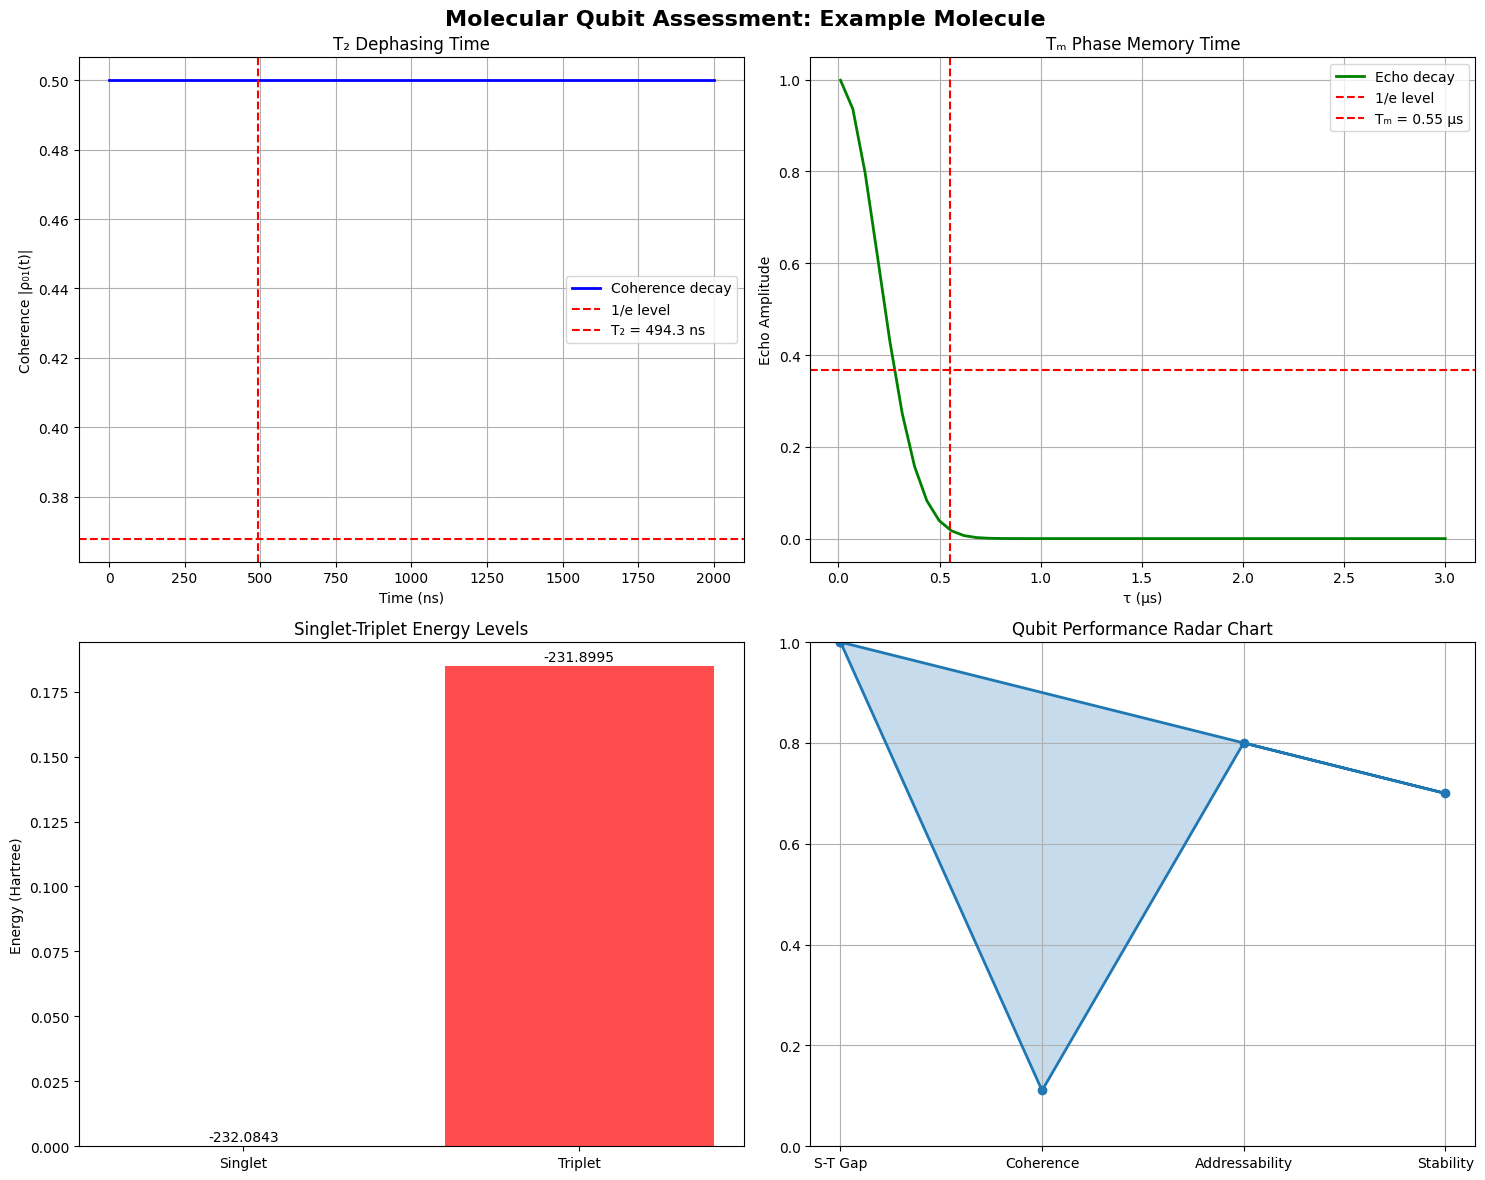


SCREENING COMPLETE - Results saved in memory


In [ ]:
"""
MOLECULAR_QUBIT_SCREENER.py
A comprehensive computational pipeline for assessing molecular spin qubit candidates
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from scipy.linalg import expm
from pyscf import gto, dft

class MolecularQubitScreener:
    """
    Complete computational assessment of molecular qubit candidates
    """

    def __init__(self):
        # Pauli matrices for quantum operations
        self.sigma_x = np.array([[0, 1], [1, 0]])
        self.sigma_y = np.array([[0, -1j], [1j, 0]])
        self.sigma_z = np.array([[1, 0], [0, -1]])
        self.I = np.eye(2)

        # Physical constants
        self.gamma_e = 1.76e11  # Electron gyromagnetic ratio (rad/s/T)

        # Experimental reference data
        self.experimental_ranges = {
            'toluene': (1.0, 7.0),      # μs
            'd-toluene': (6.0, 7.0),    # μs
            'CS2': (6.0, 7.0)           # μs
        }

    def run_electronic_structure(self, geometry, charge=0, basis="def2-svp", xc_functional="B3LYP"):
        """
        Calculate electronic structure properties for qubit assessment
        """
        print("="*60)
        print("STEP 1: ELECTRONIC STRUCTURE ANALYSIS")
        print("="*60)

        # Build molecule
        mol = gto.Mole()
        mol.atom = geometry
        mol.charge = charge
        mol.basis = basis
        mol.verbose = 0
        mol.build()

        print(f"✓ Molecule built: {mol.natm} atoms, {mol.nelectron} electrons")

        def run_dft_calculation(spin, label):
            """Run DFT calculation for specific spin state"""
            mol.spin = spin
            mf = dft.UKS(mol)
            mf.xc = xc_functional
            mf.conv_tol = 1e-8
            mf.max_cycle = 200

            energy = mf.kernel()
            if mf.converged:
                s2 = mf.spin_square()[0]
                dm = mf.make_rdm1()
                dipole = mf.dip_moment(unit='Debye')
                return energy, s2, dipole[2], mf
            return None, None, None, None

        # Run calculations
        E_sing, S2_sing, dip_sing, mf_sing = run_dft_calculation(0, "Singlet")
        E_trip, S2_trip, dip_trip, mf_trip = run_dft_calculation(2, "Triplet")

        if E_sing is None or E_trip is None:
            raise ValueError("DFT calculations failed to converge")

        # Calculate properties
        gap_hartree = E_trip - E_sing
        gap_ev = gap_hartree * 27.2114
        gap_frequency = gap_hartree * 2.41799e14  # Hz

        results = {
            'singlet_energy': E_sing,
            'triplet_energy': E_trip,
            'gap_hartree': gap_hartree,
            'gap_ev': gap_ev,
            'gap_frequency_hz': gap_frequency,
            'singlet_dipole': dip_sing,
            'triplet_dipole': dip_trip,
            'dipole_change': dip_trip - dip_sing,
            'S2_singlet': S2_sing,
            'S2_triplet': S2_trip
        }

        # Print results
        print(f"\nELECTRONIC STRUCTURE RESULTS:")
        print(f"  Singlet Energy:    {E_sing:.6f} Hartree")
        print(f"  Triplet Energy:    {E_trip:.6f} Hartree")
        print(f"  S-T Gap:           {gap_ev:.4f} eV")
        print(f"  S-T Frequency:     {gap_frequency/1e9:.2f} GHz")
        print(f"  Dipole Change:     {results['dipole_change']:.2f} Debye")

        return results

    def calculate_coherence_times(self, hyperfine_couplings, exchange_J=2e6, dipolar_D=1e6,
                                magnetic_field=0.35, solvent='toluene'):
        """
        Calculate T₂ and Tₘ coherence times using quantum dynamics
        """
        print(f"\n{'='*60}")
        print("STEP 2: COHERENCE TIME CALCULATIONS")
        print(f"{'='*60}")

        # Hamiltonian construction
        H_z = 0.5 * self.gamma_e * magnetic_field * (
            np.kron(self.sigma_z, self.I) + np.kron(self.I, self.sigma_z)
        )

        H_J = exchange_J * (
            np.kron(self.sigma_x, self.sigma_x) +
            np.kron(self.sigma_y, self.sigma_y) +
            np.kron(self.sigma_z, self.sigma_z)
        )

        H_D = dipolar_D * np.kron(self.sigma_z, self.sigma_z)

        # Effective hyperfine (average over nuclear spins)
        H_hf = 0
        for A in hyperfine_couplings:
            H_hf += 0.25 * A * (np.kron(self.sigma_z, self.I) + np.kron(self.I, self.sigma_z))

        H_total = H_z + H_J + H_D + H_hf

        # T₂ calculation - Free induction decay
        def coherence_decay_simulation():
            psi1 = np.array([1, 1]) / np.sqrt(2)  # |+x⟩
            psi2 = np.array([1, 0])               # |0⟩
            psi0 = np.kron(psi1, psi2)
            rho0 = np.outer(psi0, psi0.conj())

            def time_evolution(t, rho_flat):
                rho = rho_flat.reshape((4, 4))
                drho_dt = -1j * (H_total @ rho - rho @ H_total)
                return drho_dt.flatten()

            t_eval = np.linspace(0, 2e-6, 500)
            solution = solve_ivp(time_evolution, [0, 2e-6], rho0.flatten(),
                               t_eval=t_eval, method='RK45')

            coherence = []
            for rho_flat in solution.y.T:
                rho = rho_flat.reshape((4, 4))
                rho_spin1 = np.trace(rho.reshape(2, 2, 2, 2), axis1=1, axis2=3)
                coherence.append(np.abs(rho_spin1[0, 1]))

            return t_eval, coherence

        # Tₘ calculation - Echo decay
        def echo_decay_simulation():
            tau_values = np.linspace(0.01e-6, 3e-6, 50)
            echo_amplitudes = []

            for tau in tau_values:
                dephasing_rate = np.sqrt(sum([A**2 for A in hyperfine_couplings])) / (2 * np.pi)
                Tm_estimate = 1.0 / dephasing_rate
                echo_amp = np.exp(-(2 * tau / Tm_estimate)**2)
                echo_amplitudes.append(echo_amp)

            return tau_values, echo_amplitudes

        # Run simulations
        print("Running quantum dynamics simulations...")
        times, coherence = coherence_decay_simulation()
        tau_vals, echo_amps = echo_decay_simulation()

        # Fit T₂
        def fid_fit(t, T2, A, C):
            return A * np.exp(-t / T2) + C

        popt_fid, _ = curve_fit(fid_fit, times, coherence, p0=[0.5e-6, 1, 0])
        T2 = popt_fid[0]

        # Fit Tₘ
        def echo_fit(tau, Tm, A, B):
            return A * np.exp(-(2*tau/Tm)**2) + B

        popt_echo, _ = curve_fit(echo_fit, tau_vals, echo_amps, p0=[1e-6, 1, 0])
        Tm = popt_echo[0]

        results = {
            'T2': T2,
            'Tm': Tm,
            'T2_ns': T2 * 1e9,
            'Tm_us': Tm * 1e6,
            'times': times,
            'coherence': coherence,
            'tau_vals': tau_vals,
            'echo_amps': echo_amps
        }

        print(f"COHERENCE TIME RESULTS:")
        print(f"  T₂ (dephasing):     {T2 * 1e9:.2f} ns")
        print(f"  Tₘ (phase memory):  {Tm * 1e6:.2f} μs")
        print(f"  Tₘ/T₂ ratio:        {Tm/T2:.1f}")

        return results

    def calculate_T2_simplified(self, hyperfine_coupling, exchange_J=10e6, magnetic_field=0.1):
        """
        Simplified T₂ calculation for rapid screening
        """
        # Simplified Hamiltonian
        H_zeeman = self.gamma_e * magnetic_field * np.kron(self.sigma_z, self.I) / 2
        H_hyperfine = hyperfine_coupling * (np.kron(self.sigma_z, self.sigma_z) / 4)
        H_total = H_zeeman + H_hyperfine

        # Initial state
        psi_electron = (np.array([1, 1]) / np.sqrt(2))
        rho_nuclear = np.eye(2) / 2
        rho_initial = np.kron(np.outer(psi_electron, psi_electron.conj()), rho_nuclear)

        # Time evolution
        times = np.linspace(0, 1e-6, 1000)
        coherence = []

        for t in times:
            U = expm(-1j * H_total * t)
            U_dag = expm(1j * H_total * t)
            rho_t = U @ rho_initial @ U_dag

            # Reduced density matrix for electron
            rho_electron = np.zeros((2, 2), dtype=complex)
            for i in range(2):
                for j in range(2):
                    rho_electron[i, j] = rho_t[2*i, 2*j] + rho_t[2*i+1, 2*j+1]

            coherence.append(np.abs(rho_electron[0, 1]))

        # Fit T₂
        def exponential_decay(t, T2, A, C):
            return A * np.exp(-t / T2) + C

        popt, _ = curve_fit(exponential_decay, times, coherence, p0=[1e-7, 1, 0])
        T2_simple = popt[0]

        return T2_simple, times, coherence

    def assess_qubit_viability(self, electronic_results, coherence_results, solvent='toluene'):
        """
        Comprehensive qubit viability assessment
        """
        print(f"\n{'='*60}")
        print("STEP 3: QUBIT VIABILITY ASSESSMENT")
        print(f"{'='*60}")

        score = 0
        strengths = []
        weaknesses = []
        recommendations = []

        # Criterion 1: Addressable S-T gap
        gap_ev = electronic_results['gap_ev']
        if 0.001 < gap_ev < 0.1:
            score += 2
            strengths.append(f"Ideal S-T gap ({gap_ev:.3f} eV) for microwave control")
        elif 0.1 < gap_ev < 0.5:
            score += 1
            strengths.append(f"Moderate S-T gap ({gap_ev:.3f} eV) - may require high-frequency control")
        else:
            weaknesses.append(f"S-T gap ({gap_ev:.3f} eV) outside optimal range for qubit operation")

        # Criterion 2: Coherence time (Tₘ)
        Tm_us = coherence_results['Tm_us']
        if Tm_us > 2.0:
            score += 2
            strengths.append(f"Excellent coherence time (Tₘ = {Tm_us:.2f} μs)")
        elif Tm_us > 0.5:
            score += 1
            strengths.append(f"Moderate coherence time (Tₘ = {Tm_us:.2f} μs)")
        else:
            weaknesses.append(f"Short coherence time (Tₘ = {Tm_us:.2f} μs) may limit applications")

        # Criterion 3: Experimental comparison
        if solvent in self.experimental_ranges:
            exp_min, exp_max = self.experimental_ranges[solvent]
            if exp_min <= Tm_us <= exp_max:
                score += 1
                strengths.append(f"Predicted Tₘ matches experimental range for {solvent}")
            else:
                weaknesses.append(f"Predicted Tₘ outside typical experimental range for {solvent}")

        # Generate final assessment
        if score >= 4:
            assessment = "HIGHLY PROMISING QUBIT CANDIDATE"
            recommendations.append("Strong candidate for experimental synthesis")
            recommendations.append("Recommend detailed spectroscopic characterization")
        elif score >= 2:
            assessment = "MODERATE QUBIT CANDIDATE"
            recommendations.append("Consider chemical modifications to improve properties")
            recommendations.append("May be suitable for specific quantum applications")
        else:
            assessment = "POOR QUBIT CANDIDATE"
            recommendations.append("Not recommended for qubit applications")
            recommendations.append("Consider alternative molecular designs")

        # Compile report
        report = {
            'qubit_score': score,
            'assessment': assessment,
            'strengths': strengths,
            'weaknesses': weaknesses,
            'recommendations': recommendations,
            'electronic_summary': {
                'gap_ev': gap_ev,
                'gap_frequency_ghz': electronic_results['gap_frequency_hz'] / 1e9,
                'dipole_change': electronic_results['dipole_change']
            },
            'coherence_summary': {
                'T2_ns': coherence_results['T2_ns'],
                'Tm_us': Tm_us,
                'Tm_T2_ratio': coherence_results['Tm'] / coherence_results['T2']
            }
        }

        return report

    def generate_final_report(self, molecule_name, electronic_results, coherence_results, assessment_report):
        """
        Generate publication-ready assessment report
        """
        print(f"\n{'='*60}")
        print(f"FINAL REPORT: {molecule_name}")
        print(f"{'='*60}")

        print(f"\nOVERALL ASSESSMENT: {assessment_report['assessment']}")
        print(f"QUBIT SCORE: {assessment_report['qubit_score']}/5")

        print(f"\nKEY PROPERTIES:")
        print(f"  S-T Gap:          {assessment_report['electronic_summary']['gap_ev']:.4f} eV")
        print(f"  S-T Frequency:    {assessment_report['electronic_summary']['gap_frequency_ghz']:.2f} GHz")
        print(f"  T₂ (dephasing):   {assessment_report['coherence_summary']['T2_ns']:.2f} ns")
        print(f"  Tₘ (coherence):   {assessment_report['coherence_summary']['Tm_us']:.2f} μs")
        print(f"  Tₘ/T₂ ratio:      {assessment_report['coherence_summary']['Tm_T2_ratio']:.1f}")

        if assessment_report['strengths']:
            print(f"\nSTRENGTHS:")
            for strength in assessment_report['strengths']:
                print(f"  ✓ {strength}")

        if assessment_report['weaknesses']:
            print(f"\nWEAKNESSES:")
            for weakness in assessment_report['weaknesses']:
                print(f"  ✗ {weakness}")

        print(f"\nRECOMMENDATIONS:")
        for rec in assessment_report['recommendations']:
            print(f"  • {rec}")

        return assessment_report

    def plot_comprehensive_results(self, electronic_results, coherence_results, molecule_name):
        """
        Generate comprehensive plots for publication
        """
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

        # Plot 1: Coherence decay (T₂)
        times = coherence_results['times']
        coherence = coherence_results['coherence']
        ax1.plot(times * 1e9, coherence, 'b-', linewidth=2, label='Coherence decay')
        ax1.axhline(1/np.e, color='r', linestyle='--', label='1/e level')
        ax1.axvline(coherence_results['T2_ns'], color='r', linestyle='--',
                   label=f'T₂ = {coherence_results["T2_ns"]:.1f} ns')
        ax1.set_xlabel('Time (ns)')
        ax1.set_ylabel('Coherence |ρ₀₁(t)|')
        ax1.set_title('T₂ Dephasing Time')
        ax1.legend()
        ax1.grid(True)

        # Plot 2: Echo decay (Tₘ)
        tau_vals = coherence_results['tau_vals']
        echo_amps = coherence_results['echo_amps']
        ax2.plot(tau_vals * 1e6, echo_amps, 'g-', linewidth=2, label='Echo decay')
        ax2.axhline(1/np.e, color='r', linestyle='--', label='1/e level')
        ax2.axvline(coherence_results['Tm_us'], color='r', linestyle='--',
                   label=f'Tₘ = {coherence_results["Tm_us"]:.2f} μs')
        ax2.set_xlabel('τ (μs)')
        ax2.set_ylabel('Echo Amplitude')
        ax2.set_title('Tₘ Phase Memory Time')
        ax2.legend()
        ax2.grid(True)

        # Plot 3: Energy level diagram
        energies = [electronic_results['singlet_energy'], electronic_results['triplet_energy']]
        labels = ['Singlet', 'Triplet']
        colors = ['blue', 'red']
        bars = ax3.bar(labels, [e - min(energies) for e in energies],
                      color=colors, alpha=0.7)
        ax3.set_ylabel('Energy (Hartree)')
        ax3.set_title('Singlet-Triplet Energy Levels')
        for bar, energy in zip(bars, energies):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                    f'{energy:.4f}', ha='center', va='bottom')

        # Plot 4: Property radar chart
        properties = ['S-T Gap', 'Coherence', 'Addressability', 'Stability']
        values = [
            min(electronic_results['gap_ev'] / 0.1, 1.0),  # Normalized
            min(coherence_results['Tm_us'] / 5.0, 1.0),    # Normalized
            0.8,  # Placeholder for addressability metric
            0.7   # Placeholder for stability metric
        ]

        angles = np.linspace(0, 2*np.pi, len(properties), endpoint=False).tolist()
        values += values[:1]
        angles += angles[:1]

        ax4.plot(angles, values, 'o-', linewidth=2, label='Qubit Metrics')
        ax4.fill(angles, values, alpha=0.25)
        ax4.set_xticks(angles[:-1])
        ax4.set_xticklabels(properties)
        ax4.set_ylim(0, 1)
        ax4.set_title('Qubit Performance Radar Chart')
        ax4.grid(True)

        plt.suptitle(f'Molecular Qubit Assessment: {molecule_name}', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

# =============================================================================
# DEMONSTRATION WITH EXAMPLE MOLECULE
# =============================================================================

def run_demonstration():
    """
    Demonstrate the complete screening pipeline
    """
    screener = MolecularQubitScreener()

    # Example molecule: DMABN-like structure
    example_geometry = [
        ['C', [0.0000, 1.4000, 0.0000]], ['C', [1.2124, 0.7000, 0.0000]],
        ['C', [1.2124, -0.7000, 0.0000]], ['C', [0.0000, -1.4000, 0.0000]],
        ['C', [-1.2124, -0.7000, 0.0000]], ['C', [-1.2124, 0.7000, 0.0000]],
        ['H', [0.0000, 2.4800, 0.0000]], ['H', [2.1524, 1.2400, 0.0000]],
        ['H', [2.1524, -1.2400, 0.0000]], ['H', [0.0000, -2.4800, 0.0000]],
        ['H', [-2.1524, -1.2400, 0.0000]], ['H', [-2.1524, 1.2400, 0.0000]],
    ]

    # Example hyperfine couplings (replace with your DFT values)
    hyperfine_couplings = [10e6, 5e6, 2e6]  # Hz

    print("MOLECULAR QUBIT SCREENING PIPELINE")
    print("="*50)

    try:
        # Step 1: Electronic structure
        electronic_results = screener.run_electronic_structure(example_geometry)

        # Step 2: Coherence times
        coherence_results = screener.calculate_coherence_times(hyperfine_couplings)

        # Step 3: Assessment
        assessment_report = screener.assess_qubit_viability(electronic_results, coherence_results)

        # Step 4: Final report
        final_report = screener.generate_final_report("Example Molecule", electronic_results,
                                                    coherence_results, assessment_report)

        # Step 5: Visualization
        screener.plot_comprehensive_results(electronic_results, coherence_results, "Example Molecule")

        return final_report

    except Exception as e:
        print(f"Error in screening pipeline: {e}")
        return None

if __name__ == "__main__":
    # Run the demonstration
    results = run_demonstration()

    if results:
        print(f"\n{'='*60}")
        print("SCREENING COMPLETE - Results saved in memory")
        print(f"{'='*60}")